# Customer Churn Prediction: End-to-End ML Pipeline
This notebook implements an advanced, end-to-end Machine Learning pipeline to predict customer churn based on demographics, usage, and engagement features.

## Phase 1: Deep Workspace Analysis & EDA
In this phase, we load the dataset, perform essential cleaning, formulate the target variable (Binary Classification: Stayed vs. Churned), and visualize class imbalance and feature distributions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (8, 5)})

# 1. Load the dataset
data_path = '../data/telecom_customer_churn.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (7043, 38)


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [2]:
# 2. Data Cleaning & Target Variable Definition
cols_to_drop = ['Customer ID', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Churn Category', 'Churn Reason']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# Handle the Target Variable
df_clean = df_clean[df_clean['Customer Status'].isin(['Churned', 'Stayed'])].copy()
df_clean['Churn'] = df_clean['Customer Status'].map({'Churned': 1, 'Stayed': 0})
df_clean.drop('Customer Status', axis=1, inplace=True)

# Handle string/numeric coercion gracefully
if 'Total Charges' in df_clean.columns:
    df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')

# Pipeline Imputation Delegated: No global imputation here
print("Dataset shape after structural cleaning:", df_clean.shape)

Dataset shape after structural cleaning: (6589, 31)


Class Imbalance:
Churn
0    71.634542
1    28.365458
Name: proportion, dtype: float64


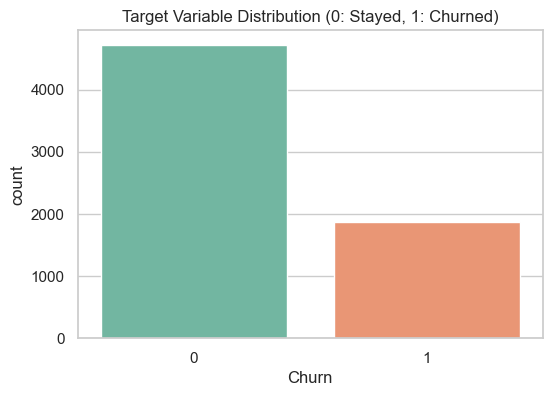

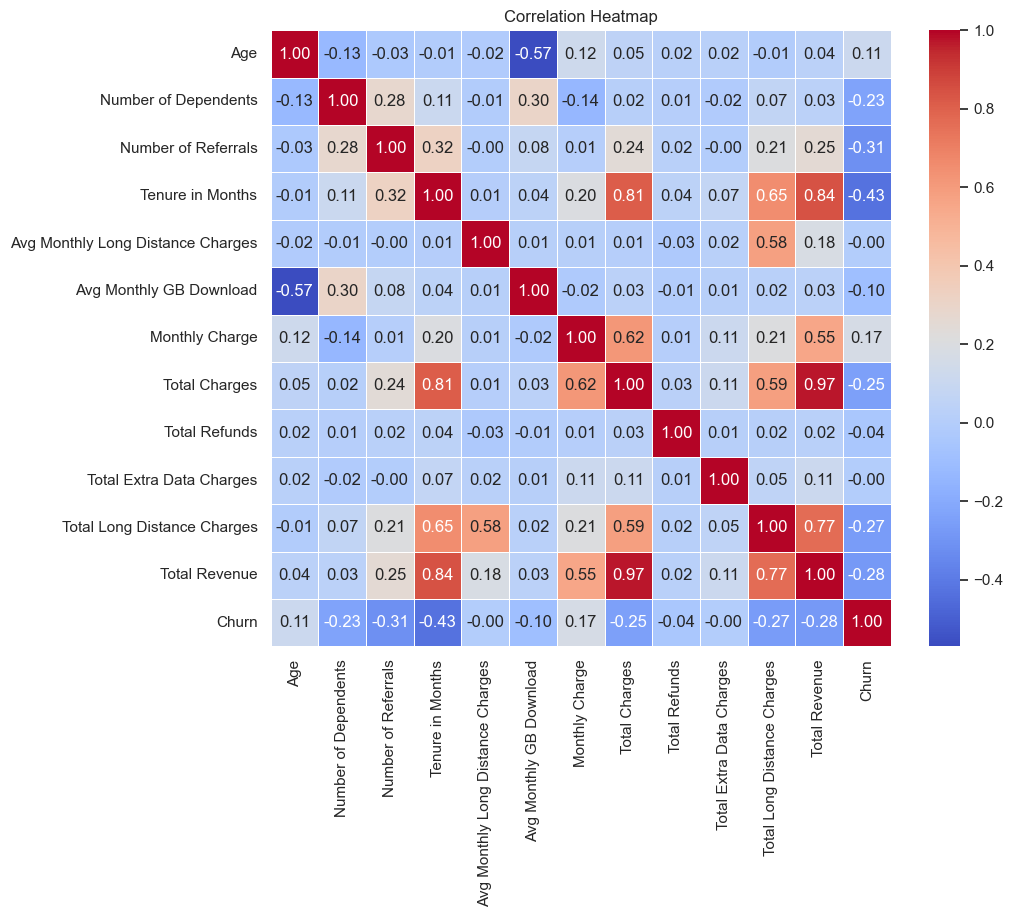

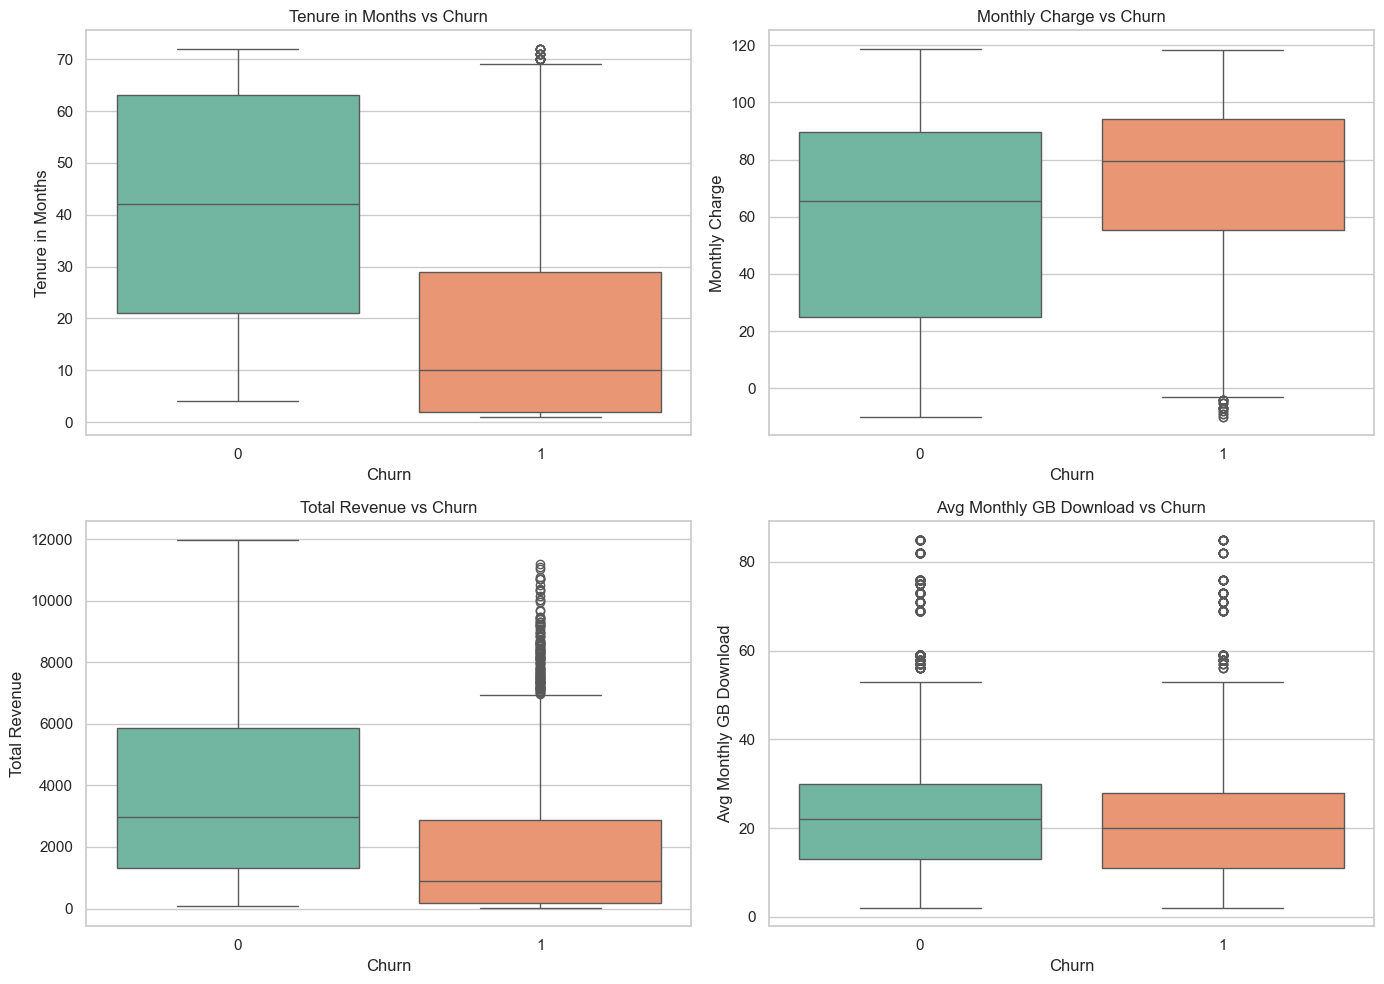

In [3]:
# 4. Exploratory Data Analysis (EDA)
# Class Imbalance
class_counts = df_clean['Churn'].value_counts(normalize=True) * 100
print(f"Class Imbalance:\n{class_counts}")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Churn', palette='Set2')
plt.title('Target Variable Distribution (0: Stayed, 1: Churned)')
plt.show()

# Numerical Features Correlation Heatmap
num_cols = df_clean.select_dtypes(include=np.number).columns.drop('Churn', errors='ignore')
plt.figure(figsize=(10, 8))
corr = df_clean[num_cols.tolist() + ['Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Boxplots for numerical features vs Churn
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()
key_num_features = ['Tenure in Months', 'Monthly Charge', 'Total Revenue', 'Avg Monthly GB Download']
for i, col in enumerate(key_num_features):
    if col in df_clean.columns:
        sns.boxplot(data=df_clean, x='Churn', y=col, ax=axes[i], palette='Set2')
        axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

## Phase 2: Advanced Feature Engineering
We will create derived features from raw engagement/demographics to capture "velocity" or "ratios" which often hold more predictive power than absolute values, and then prepare the categorical variables.

In [4]:
# 1. Advanced Derived Features (Vectorized)
import numpy as np

if "Total Revenue" in df_clean.columns and "Tenure in Months" in df_clean.columns:
    df_clean['Revenue_per_Tenure'] = np.where(df_clean['Tenure in Months'] == 0, 0, df_clean['Total Revenue'] / df_clean['Tenure in Months'])

if "Total Charges" in df_clean.columns and "Tenure in Months" in df_clean.columns:
    df_clean['Charges_per_Month'] = np.where(df_clean['Tenure in Months'] == 0, 0, df_clean['Total Charges'] / df_clean['Tenure in Months'])

# Service Count Vectorization
services = ['Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music']
existing_services = [s for s in services if s in df_clean.columns]
if existing_services:
    df_clean['Total_Services'] = (df_clean[existing_services] == 'Yes').sum(axis=1)

if 'Age' in df_clean.columns:
    df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 30, 50, 70, 120], labels=['Young', 'Adult', 'Senior', 'Elderly']).astype(str)
    df_clean.drop('Age', axis=1, inplace=True)

X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

## Phase 3: Robust ML Pipeline Construction
Constructing a `Pipeline` incorporating a `ColumnTransformer` (for `RobustScaler` and `OneHotEncoder`). We will explicitly handle the class imbalance using algorithm-level class weights rather than SMOTE to ensure performance without requiring external imbalance-learn dependencies.

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ]
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': HistGradientBoostingClassifier(class_weight='balanced', random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Phase 4: Model Selection & Optimization
We evaluate the baseline models using `StratifiedKFold` cross-validation and then perform hyperparameter tuning on the Gradient Boosting model using `RandomizedSearchCV`.

In [6]:
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

print("Cross-Validation ROC-AUC Scores:")
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='roc_auc')
    print(f"{name:20s} - Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Hyperparameter Tuning for Gradient Boosting
print("\nInitiating RandomizedSearchCV for Gradient Boosting...")
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'classifier__max_iter': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, None],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__l2_regularization': [0.0, 0.1, 1.0]
}

rs = RandomizedSearchCV(gb_pipeline, param_distributions=param_grid, n_iter=10, cv=skf, scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train, y_train)

print(f"\nBest Parameters for Gradient Boosting: {rs.best_params_}")
print(f"Best CV ROC-AUC: {rs.best_score_:.4f}")
best_model = rs.best_estimator_

Cross-Validation ROC-AUC Scores:


Logistic Regression  - Mean ROC-AUC: 0.9144 (+/- 0.0108)


Random Forest        - Mean ROC-AUC: 0.9210 (+/- 0.0083)


Gradient Boosting    - Mean ROC-AUC: 0.9308 (+/- 0.0071)

Initiating RandomizedSearchCV for Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits



Best Parameters for Gradient Boosting: {'classifier__max_iter': 300, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__l2_regularization': 1.0}
Best CV ROC-AUC: 0.9357


## Phase 5: Advanced Evaluation & Business Context
Evaluating on the unseen test set, calculating Precision, Recall, F1-Score, and plotting the ROC and Precision-Recall curves.

### Business Context: False Positives vs. False Negatives
- **False Positives (Predicted Churn, Actually Stayed):** The business spends money on retention campaigns for a customer who was not going to leave.
- **False Negatives (Predicted Stay, Actually Churned):** The business loses the customer completely without attempting intervention.

**Strategy:** In churn prediction, False Negatives usually incur a much higher cost (lost Customer Lifetime Value) compared to False Positives (cost of a promotion). Therefore, a model with high **Recall** is preferred to capture as many potential churners as possible.

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.87       944
           1       0.66      0.80      0.73       374

    accuracy                           0.83      1318
   macro avg       0.79      0.82      0.80      1318
weighted avg       0.84      0.83      0.83      1318



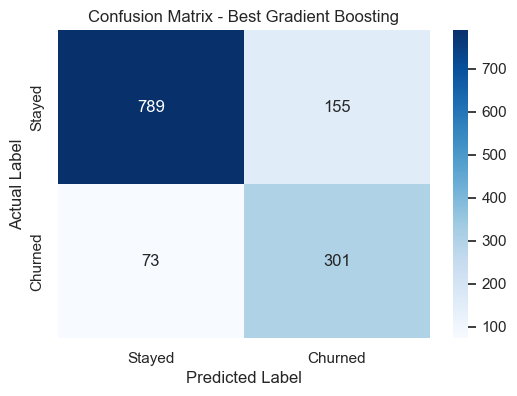

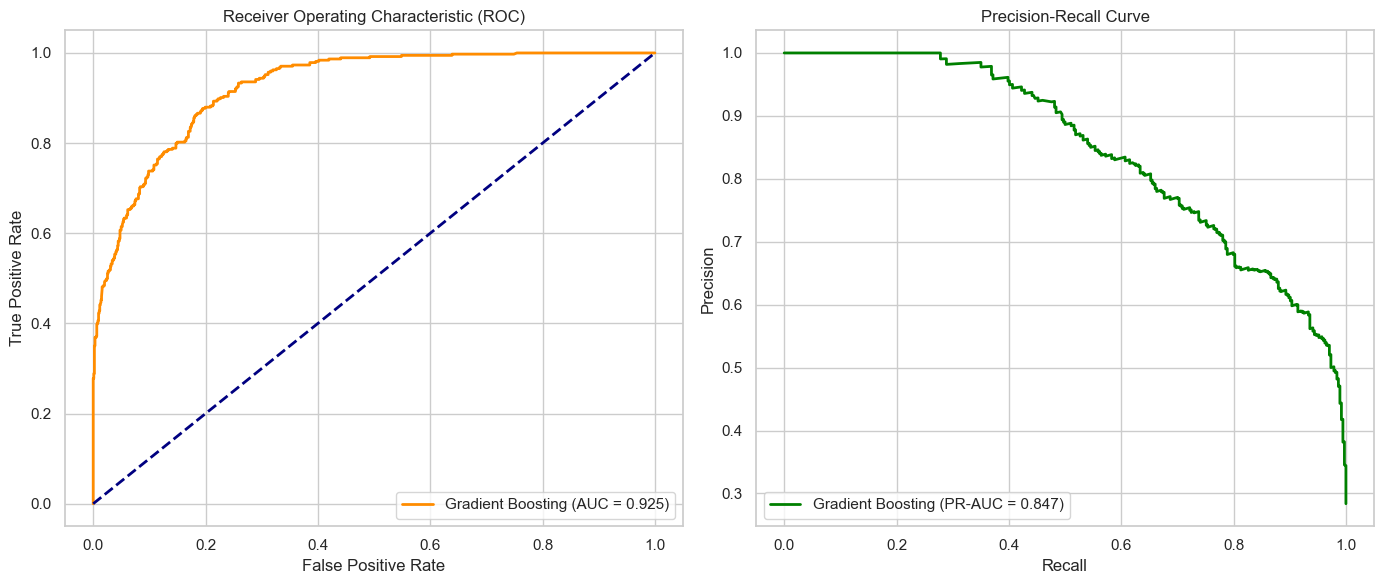

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix, classification_report, f1_score

# Predictions
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix - Best Gradient Boosting')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC & PR Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Gradient Boosting (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)')
axes[0].legend(loc="lower right")

# 2. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='green', lw=2, label=f'Gradient Boosting (PR-AUC = {pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## Phase 6: Model Explainability
Extracting feature importances and utilizing **SHAP (SHapley Additive exPlanations)** to demystify our black-box model and identify the core drivers of churn.

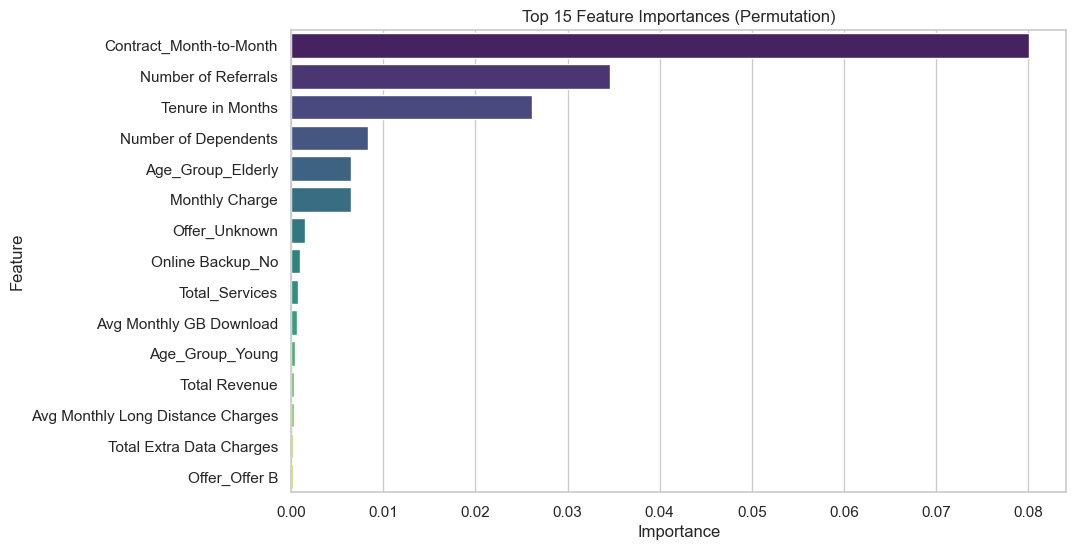

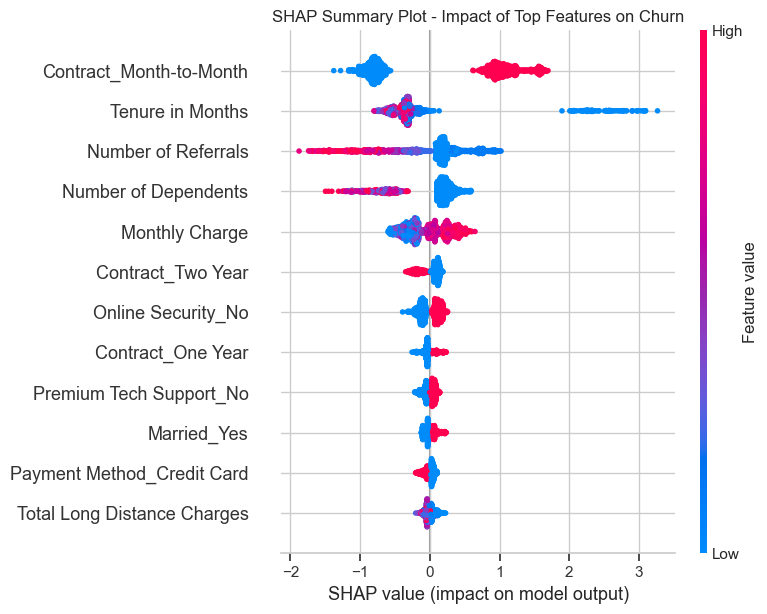

Generating SHAP dependence plot for the top feature: Contract_Month-to-Month


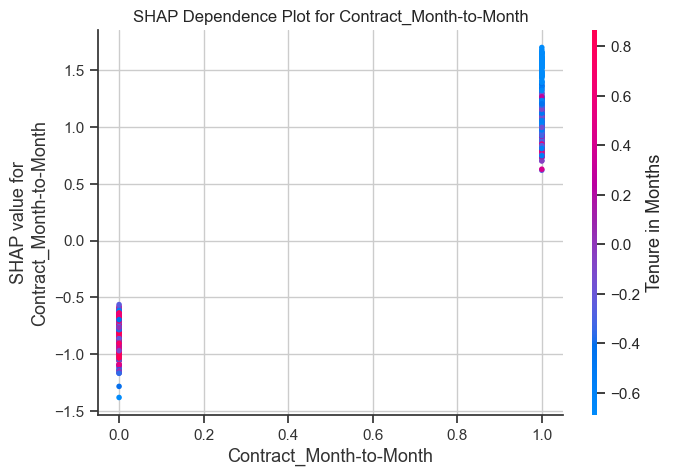

In [8]:
import shap
from sklearn.inspection import permutation_importance

# 1. Global Feature Importances using Permutation Importance
# Note: n_jobs=1 is set deliberately to avoid a BrokenProcessPool error that
# occurs when joblib workers inherit a stale numpy version in a multiprocessing context.
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(cat_cols).tolist()
all_features = num_cols + cat_features

# Transform X_test to a dense DataFrame for compatibility
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_features)

classifier = best_model.named_steps['classifier']

# n_jobs=1: avoids multiprocessing/joblib BrokenProcessPool numpy version conflict
result = permutation_importance(classifier, X_test_transformed_df, y_test, n_repeats=5, random_state=42, n_jobs=1)
importances = result.importances_mean

feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Permutation)')
plt.show()

# 2. SHAP Values
try:
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_test_transformed_df)
except Exception:
    explainer = shap.Explainer(classifier.predict, X_test_transformed_df.sample(200, random_state=42))
    shap_values = explainer(X_test_transformed_df.sample(200, random_state=42))

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
if isinstance(shap_values, np.ndarray):
    shap.summary_plot(shap_values, X_test_transformed_df, max_display=12, show=False)
else:
    shap.summary_plot(shap_values.values, shap_values.data, feature_names=all_features, max_display=12, show=False)
plt.title('SHAP Summary Plot - Impact of Top Features on Churn')
plt.tight_layout()
plt.show()

# Partial Dependence Plot for a top feature
top_feature_idx = np.argmax(importances)
top_feature_name = all_features[top_feature_idx]

print(f"Generating SHAP dependence plot for the top feature: {top_feature_name}")
if isinstance(shap_values, np.ndarray):
    shap.dependence_plot(top_feature_idx, shap_values, X_test_transformed_df, feature_names=all_features, show=False)
else:
    shap.dependence_plot(top_feature_idx, shap_values.values, shap_values.data, feature_names=all_features, show=False)
plt.title(f'SHAP Dependence Plot for {top_feature_name}')
plt.show()